In [1]:
import json, polars as pl
from pathlib import Path
from IPython.display import Image, Markdown, display
ROOT = Path.cwd().parent
T = ROOT / "reports" / "tables"; F = ROOT / "reports" / "figures"
pl.Config.set_tbl_rows(40); pl.Config.set_tbl_cols(20); pl.Config.set_tbl_width_chars(200)
def show(p): display(Image(filename=str(p)))
def tab(p, cols=None):
    d = pl.read_csv(p); return d.select(cols) if cols else d

# 06 · Walk-forward validation
Expanding window, 3-month validation blocks, purge (labels may not cross into the embargo) and a 1-day embargo. Random cross-validation is not used: neighbouring minutes share overlapping labels and regimes, so shuffling would leak future information into training.

In [2]:
tab(T / 'walk_forward_folds.csv')

name,train_start,train_end,valid_start,valid_end
str,str,str,str,str
"""F1""","""2023-03-01T00:00:00+00:00""","""2024-02-29T00:00:00+00:00""","""2024-03-01T00:00:00+00:00""","""2024-06-01T00:00:00+00:00"""
"""F2""","""2023-03-01T00:00:00+00:00""","""2024-05-31T00:00:00+00:00""","""2024-06-01T00:00:00+00:00""","""2024-09-01T00:00:00+00:00"""
"""F3""","""2023-03-01T00:00:00+00:00""","""2024-08-31T00:00:00+00:00""","""2024-09-01T00:00:00+00:00""","""2024-12-01T00:00:00+00:00"""
"""F4""","""2023-03-01T00:00:00+00:00""","""2024-11-30T00:00:00+00:00""","""2024-12-01T00:00:00+00:00""","""2025-03-01T00:00:00+00:00"""
"""F5""","""2023-03-01T00:00:00+00:00""","""2025-02-28T00:00:00+00:00""","""2025-03-01T00:00:00+00:00""","""2025-06-01T00:00:00+00:00"""
"""F6""","""2023-03-01T00:00:00+00:00""","""2025-05-31T00:00:00+00:00""","""2025-06-01T00:00:00+00:00""","""2025-09-01T00:00:00+00:00"""
"""F7""","""2023-03-01T00:00:00+00:00""","""2025-08-31T00:00:00+00:00""","""2025-09-01T00:00:00+00:00""","""2025-10-01T00:00:00+00:00"""


In [3]:
tab(T / 'model_folds_all.csv').filter(pl.col('config') == json.loads((T / 'primary_model_selection.json').read_text())['selected']).select('fold','valid_start','n_train','n','auc','log_loss','log_loss_baseline','ece','ic_spearman')

fold,valid_start,n_train,n,auc,log_loss,log_loss_baseline,ece,ic_spearman
str,str,i64,i64,f64,f64,f64,f64,f64
"""F1""","""2024-03-01""",35039,132465,0.538643,0.690889,0.693119,0.011973,0.055041
"""F2""","""2024-06-01""",43871,132465,0.547158,0.689912,0.693143,0.008438,0.072111
"""F3""","""2024-09-01""",52703,131025,0.541155,0.690506,0.693097,0.008269,0.063839
"""F4""","""2024-12-01""",61439,129585,0.526496,0.693025,0.693142,0.019182,0.036007
"""F5""","""2025-03-01""",70079,132465,0.534151,0.691212,0.693047,0.015104,0.047785
"""F6""","""2025-06-01""",78911,132465,0.529157,0.692222,0.692874,0.020446,0.044101
"""F7""","""2025-09-01""",87743,43185,0.549622,0.689789,0.693146,0.011871,0.081363


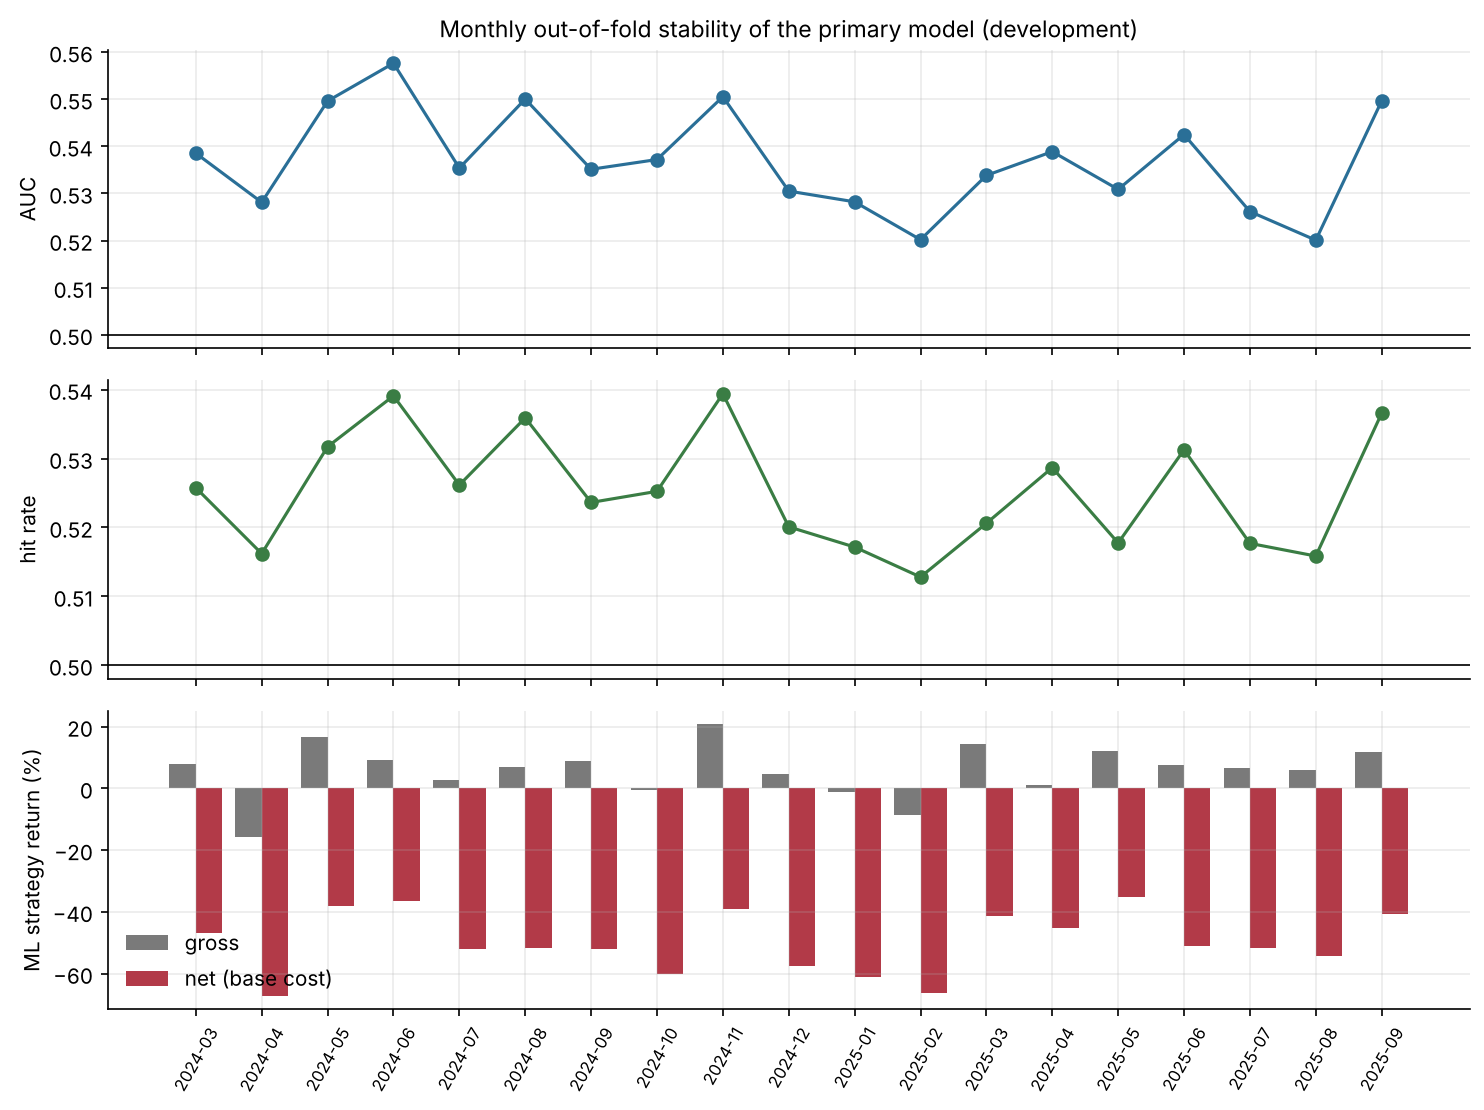

In [4]:
show(F / 'dev/dev_monthly_stability.png')